## Dataset Preparation
Feature and Target Sepearation

In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('../data/names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(set(''.join(words)))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {s:i for i,s in stoi.items()}

# itos[1] = 'a'
# stoi['a'] = 1

In [10]:
CONTEXT_SIZE = 3

X = []
y = []
for w in words:
    # print(w)
    context = [0] * CONTEXT_SIZE
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)

        context = context[1:] + [ix]
        # print(''.join(itos[i] for i in context), '--->', itos[ix])


# X is [x1, x2, x3, ... xN] 
X = torch.tensor(X)
y = torch.tensor(y)

In [11]:
DIM_SIZE = 2

# C is an embedded dimension
C = torch.randn((27, DIM_SIZE))

# OHE, but we do it algebraically (it's the same zero cancel out effect)
emb = C[X]

print(X.shape)
print(C.shape)
print(emb.shape)

torch.Size([228146, 3])
torch.Size([27, 2])
torch.Size([228146, 3, 2])


In [12]:
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, 100))
B1 = torch.randn(100)

h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + B1)
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn((100, 27))
B2 = torch.randn(27)

logits = h @ W2 + B2
counts = logits.exp()
probs = counts/counts.sum(1, keepdims=True)


## Unified Version

In [ ]:
CONTEXT_SIZE = 3

def build_dataset(words):
    X = []
    y = []
    for w in words:
        # print(w)
        context = [0] * CONTEXT_SIZE
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)

            context = context[1:] + [ix]
            # print(''.join(itos[i] for i in context), '--->', itos[ix])


    # X is [x1, x2, x3, ... xN] 
    X = torch.tensor(X)
    y = torch.tensor(y)

    return X, y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, y_train = build_dataset(words[:n1])
X_dev, y_dev = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

torch.Size([182437, 3])
torch.Size([22781, 3])
torch.Size([22928, 3])


In [116]:
g  = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, DIM_SIZE), generator=g) 
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [117]:
import torch.nn.functional as F

epochs = 30000
batch  = 64
lr = 0.001


lre = torch.linspace(-3, 0, epochs)
lrs = 10**lre

lri = []
lossi = []
stepi = []

In [ ]:
for i in range(epochs):
    # forward pass
    ix = torch.randint(0, X_train.shape[0], (batch,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data -= lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

    if i % 100 == 0:
        print(f'loss {i}-{loss.item()}')

26.797021865844727
14.627713203430176
10.25590991973877
7.289827346801758
7.943278789520264
5.076182842254639
4.697486877441406
5.442043781280518
4.030169486999512
3.5721421241760254
3.3224871158599854
3.7534687519073486
3.954116106033325
3.282804012298584
2.709242105484009
3.0855493545532227
3.121222496032715
3.0800178050994873
3.4044389724731445
3.010762929916382
2.9788408279418945
2.937706470489502
2.9398603439331055
2.6097497940063477
3.367536783218384
2.861055612564087
2.6533682346343994
2.6500887870788574
2.834899663925171
2.7809619903564453
2.7771193981170654
2.974492073059082
2.897538423538208
2.7929744720458984
2.5633652210235596
2.7078192234039307
2.712395429611206
2.636387586593628
2.705993413925171
2.595292568206787
2.6593692302703857
2.7532172203063965
2.530607223510742
2.66059947013855
2.5122992992401123
2.5436220169067383
2.7307238578796387
2.4925105571746826
2.3577044010162354
2.5616631507873535
2.5902788639068604
2.2588162422180176
2.3766181468963623
2.487520694732666


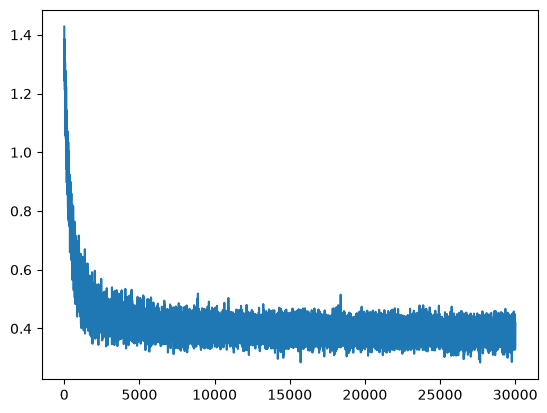

In [123]:
plt.plot(stepi, lossi)

In [124]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, y_train)

loss.item()

2.4438862800598145

In [125]:
emb = C[X_dev]
h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, y_dev)

loss.item()

2.456449031829834

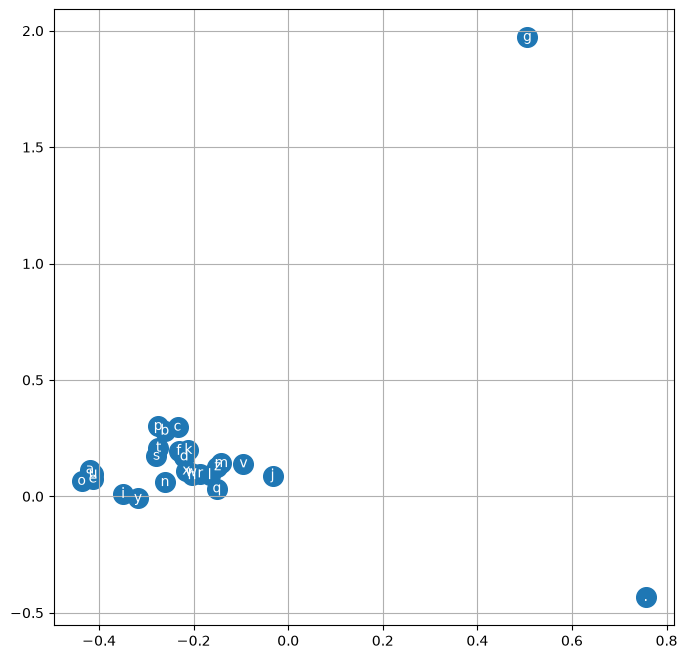

In [126]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [129]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * CONTEXT_SIZE # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

careah.
aal.
havi.
kimle.
rehty.
salass.
enrahnen.
deliaha.
kaeni.
nelania.
ceriiv.
kale.
gyo.
bha.
kin.
qainn.
sroin.
alia.
biur.
jero.
